# 📅 Seasonal Performance Analysis

**Goal**: Analyze how athlete performance evolves throughout a calendar year. Identify peaks, seasonal trends (Indoor vs. Outdoor), and visualize the "heartbeat" of the athletics season.

In [16]:
import pandas as pd
import numpy as np
import sys
import os
from sklearn.linear_model import LinearRegression

# Add project root to path to import util and plotting modules
sys.path.append(os.path.abspath(os.path.join('..', '..')))

import util
import plotting.plotting_style as plt
from plotting.plotting_style import rgb
import plotting.plotting_style


# Load the data
df = util.load_data('../../data_csv/final_Data_iaaf_scores_neu.csv', youth=True)
df.head()

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score
0,2017,W,Frauen,100 m,10.95,1.3,Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211
1,2017,W,Frauen,100 m,11.06,1.8,Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187
2,2017,W,Frauen,100 m,11.14,-0.2,Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169
3,2017,W,Frauen,100 m,11.24,0.3,Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148
4,2017,W,Frauen,100 m,11.25,1.9,Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146


## 1. Date Preprocessing
The `datum` column contains mixed formats (e.g., "05.08." without year, or "29.04.2023" with year). We need to parse this into a proper datetime object and extract the **Day of Year (1-366)**.

In [17]:
def parse_german_date(row):
    date_str = row['datum']
    year_col = row['jahr']
    
    if pd.isna(date_str):
        return pd.NaT
    
    date_str = str(date_str).strip()
    
    # Attempt 1: Full date format "dd.mm.yyyy"
    try:
        return pd.to_datetime(date_str, format='%d.%m.%Y')
    except ValueError:
        pass
    
    # Attempt 2: Short format "dd.mm." (year is missing, take from 'jahr' col)
    try:
        # Remove trailing dot if present
        clean_str = date_str.rstrip('.')
        # Parse as day.month
        temp_date = pd.to_datetime(clean_str, format='%d.%m')
        # Replace the default 1900 year with the actual year from the dataset
        return temp_date.replace(year=int(year_col))
    except ValueError:
        return pd.NaT

# Apply the parser (this might take a moment)
print("Parsing dates...")
df['parsed_date'] = df.apply(parse_german_date, axis=1)

# Drop rows where date parsing failed
df_clean = df.dropna(subset=['parsed_date']).copy()

# Extract 'Day of Year' for seasonality comparison
df_clean['day_of_year'] = df_clean['parsed_date'].dt.dayofyear

print(f"Successfully parsed {len(df_clean)} / {len(df)} dates.")
df_clean[['datum', 'jahr', 'parsed_date', 'day_of_year']].head()

Parsing dates...
Successfully parsed 186304 / 193191 dates.


,datum,jahr,parsed_date,day_of_year
0,05.08.,2017,2017-08-05,217
1,25.05.,2017,2017-05-25,145
2,27.08.,2017,2017-08-27,239
3,15.07.,2017,2017-07-15,196
4,11.06.,2017,2017-06-11,162


## 2. Single Year Analysis (e.g., 2019)
Let's look at a single, pre-pandemic year to understand the typical structure.
We calculate the **daily mean IAAF score** to see when the "best" performances happen.

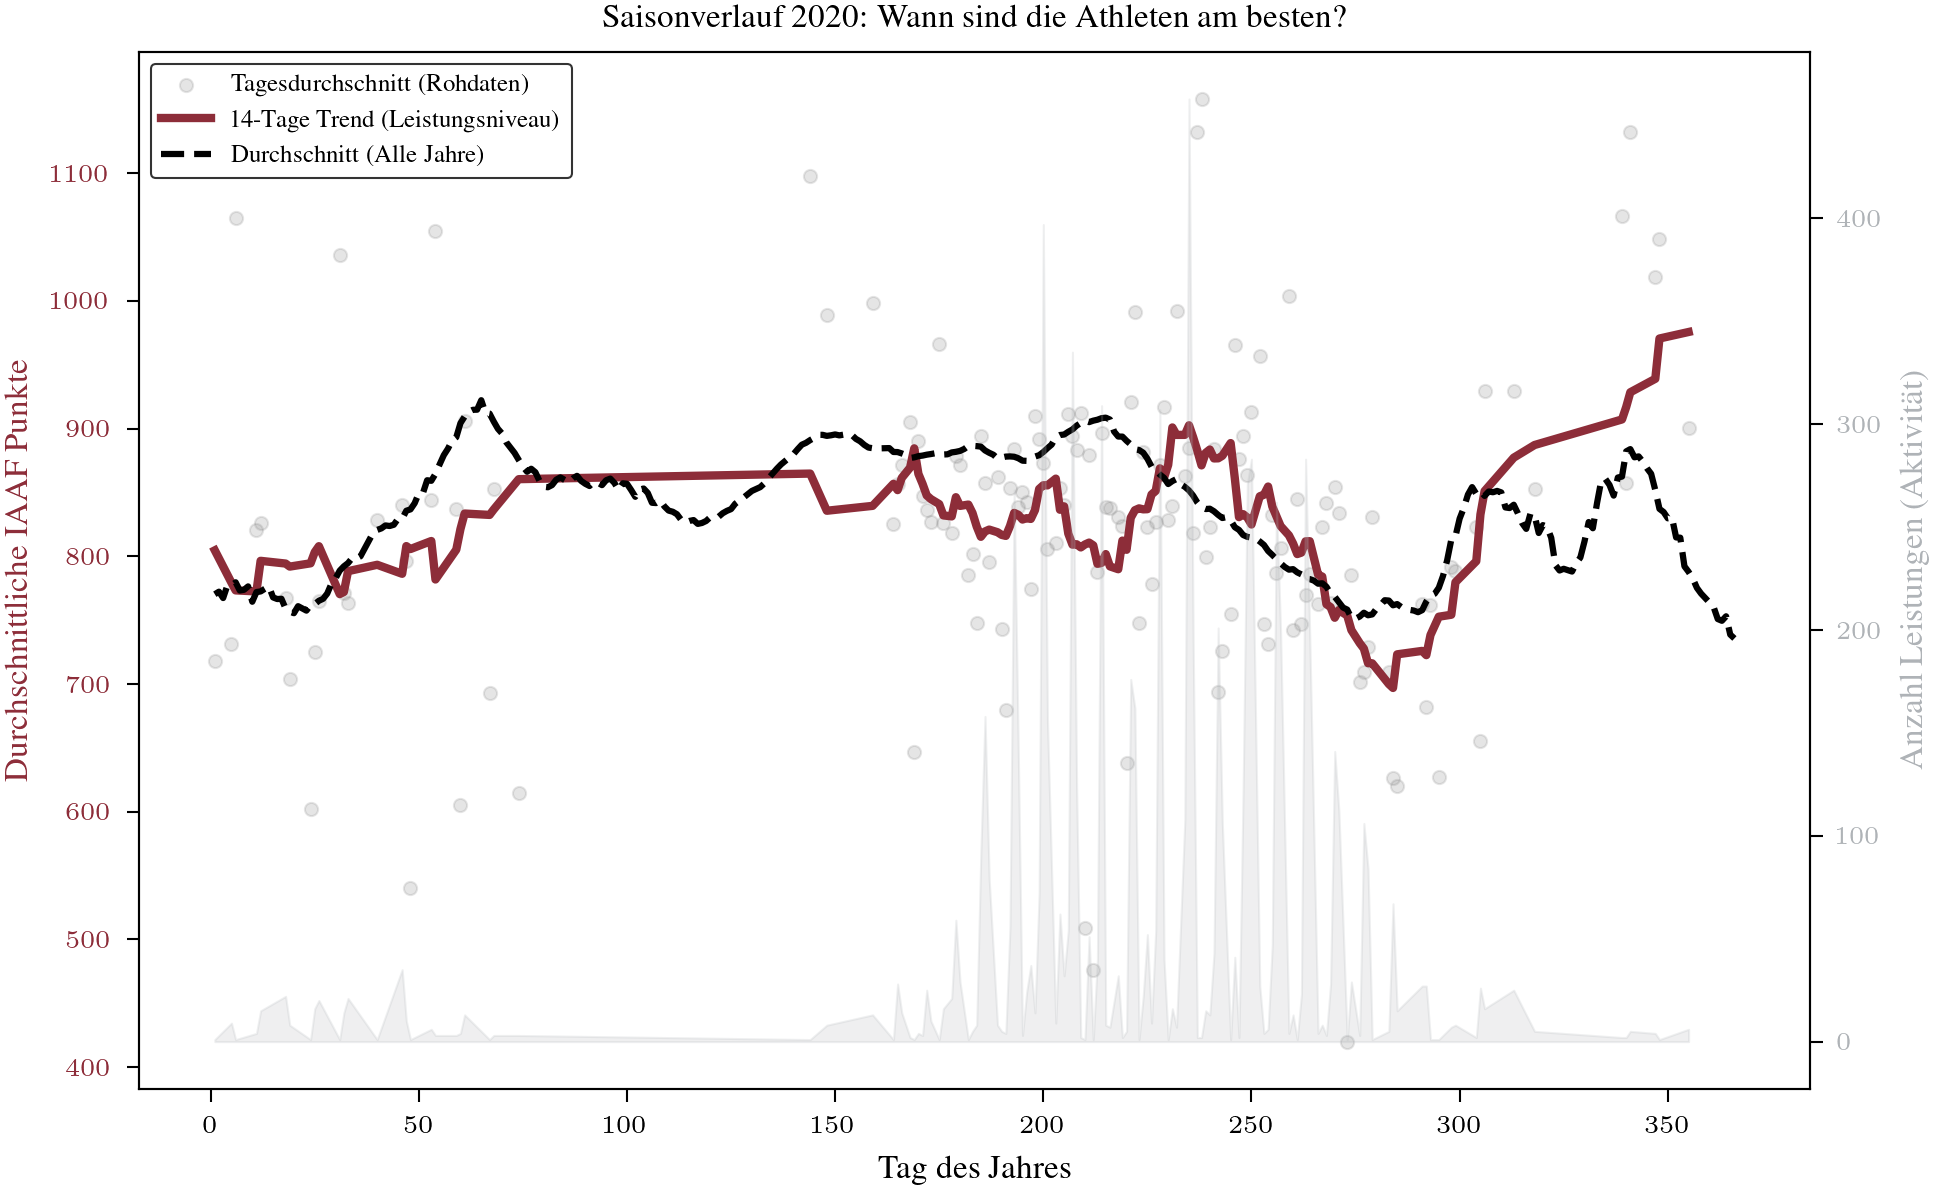

In [18]:
target_year = 2020
df_year = df_clean[df_clean['jahr'] == target_year]

# Aggregate by Day of Year
# We calculate mean score and the count of competitions per day
daily_stats = df_year.groupby('day_of_year')['iaaf_score'].agg(['mean', 'count'])

# Rolling Average to smooth out weekend spikes (7-day window)
daily_stats['smoothed_mean'] = daily_stats['mean'].rolling(window=14, center=True, min_periods=1).mean()

# Calculate global mean across ALL years for comparison
global_stats = df_clean.groupby('day_of_year')['iaaf_score'].mean()
global_smoothed = global_stats.rolling(window=14, center=True, min_periods=1).mean()

# Plotting
with plt.rc_context(plt.increase_figsize(2)):
    fig, ax1 = plt.subplots()

    # Plot Mean Score
    ax1.scatter(daily_stats.index, daily_stats['mean'], alpha=0.2, color='gray', s=10, label='Tagesdurchschnitt (Rohdaten)')
    ax1.plot(daily_stats.index, daily_stats['smoothed_mean'], color=rgb.tue_red, linewidth=2, label='14-Tage Trend (Leistungsniveau)')
    
    # Add Global Mean
    ax1.plot(global_smoothed.index, global_smoothed, color='black', linestyle='--', linewidth=1.5, label='Durchschnitt (Alle Jahre)')

    ax1.set_xlabel('Tag des Jahres')
    ax1.set_ylabel('Durchschnittliche IAAF Punkte', color=rgb.tue_red)
    ax1.tick_params(axis='y', labelcolor=rgb.tue_red)

    # Create a twin axis to show the density of competitions (Number of results)
    ax2 = ax1.twinx()
    ax2.fill_between(daily_stats.index, daily_stats['count'], color=rgb.tue_gray, alpha=0.2, label='Anzahl Leistungen')
    ax2.set_ylabel('Anzahl Leistungen (Aktivität)', color=rgb.tue_gray)
    ax2.tick_params(axis='y', labelcolor=rgb.tue_gray)

    # Annotations for Seasons
    plt.title(f'Saisonverlauf {target_year}: Wann sind die Athleten am besten?')
    ax1.legend()

    plt.show()

## 3. Multi-Year Analysis (The COVID-19 Impact)
We overlay all years to see the general pattern, but we **highlight 2020** to visualize the disruption caused by the pandemic.

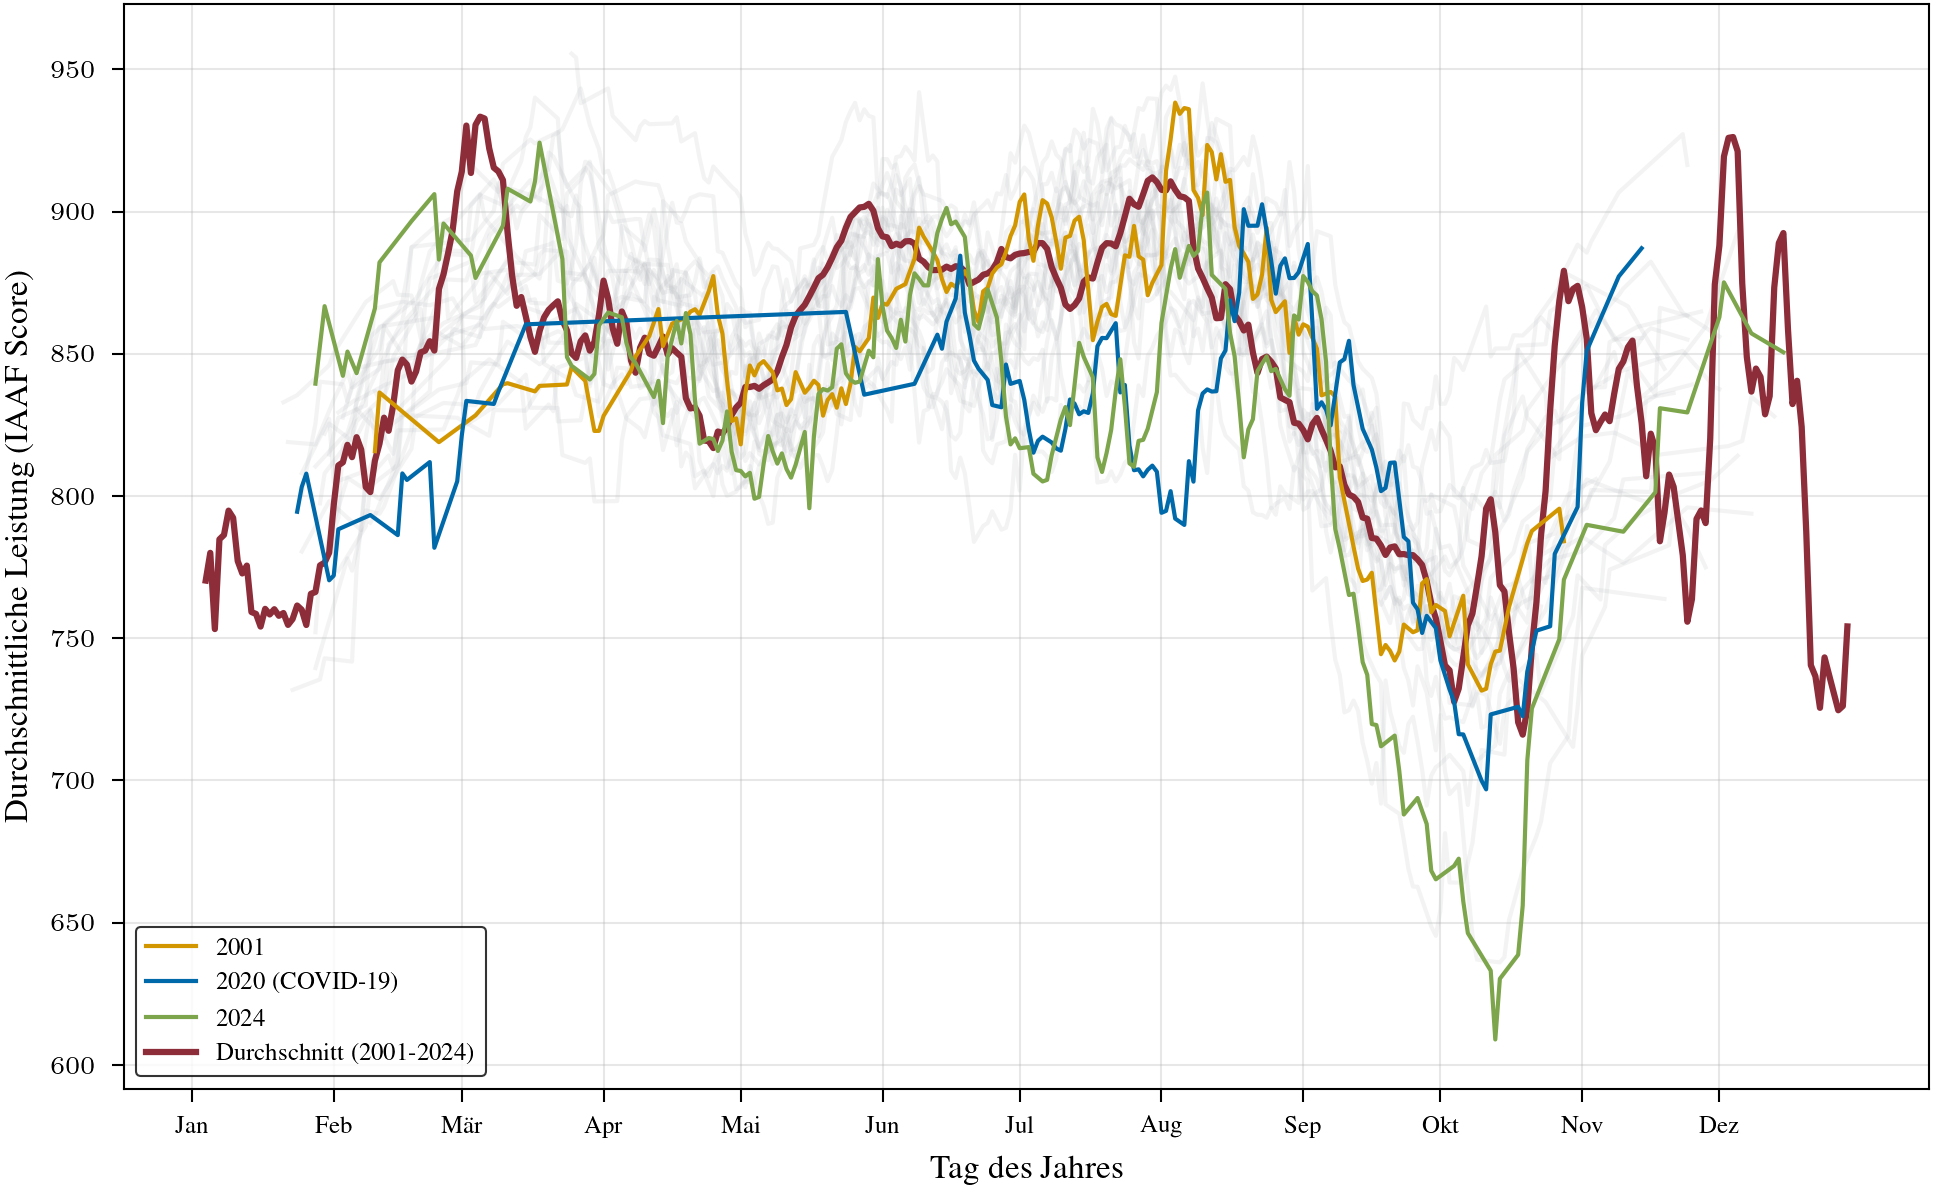

In [19]:
# Group by Day of Year across ALL years
global_stats = df_clean.groupby('day_of_year')['iaaf_score'].mean()
global_smoothed = global_stats.rolling(window=7, center=True).mean()

with plt.rc_context(plt.increase_figsize(2)):

    years = df_clean['jahr'].unique()
    for y in years:
        y_data = df_clean[df_clean['jahr'] == y].groupby('day_of_year')['iaaf_score'].mean().rolling(window=14, center=True).mean()
        
        # Logic to highlight 2020
        if y == 2001:
            plt.plot(y_data.index, y_data, color=rgb.tue_orange, alpha=1.0, linewidth=1.0, label='2001', zorder=10)
        elif y == 2024:
            plt.plot(y_data.index, y_data, color=rgb.tue_green, alpha=1.0, linewidth=1.0, label='2024', zorder=10)
        elif y == 2020:
            plt.plot(y_data.index, y_data, color=rgb.tue_blue, alpha=1.0, linewidth=1.0, label='2020 (COVID-19)', zorder=10)
        else:
            # plt.plot(y_data.index, y_data, color=rgb.tue_gray, alpha=((y - 2001) / (2024 - 2001)) / 2, linewidth=1)
            plt.plot(y_data.index, y_data, color=rgb.tue_gray, alpha=0.15, linewidth=1)

    # Plot the global average
    plt.plot(global_smoothed.index, global_smoothed, color=rgb.tue_red, linewidth=1.5, label='Durchschnitt (2001-2024)', zorder=5)

    # plt.title('Der "Herzschlag" der Saison: Der Einbruch durch COVID-19 (2020)')
    plt.xlabel('Tag des Jahres')
    plt.ylabel('Durchschnittliche Leistung (IAAF Score)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # X-Axis formatting to Months
    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_names = ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']
    plt.xticks(month_starts, month_names)

    plt.savefig('seasonal_performance_youth')
    plt.show()


### **Observations (2020)**
The 2020 line (blue) clearly shows:
1.  **Normal Indoor Season**: The year started normally (Jan-Feb).
2.  **Lockdown Gap**: A massive gap in March/April/May where competitions ceased.
3.  **Late Start**: The outdoor season started much later (July/August) than usual.

## 4. Trend Analysis: Is the "Outdoor Peak" Shifting?

**Question**: Has the time of peak performance shifted over the last 20+ years (e.g., due to climate change or later championships)?

**Methodology**:
1. For each year, we identify the **day of the year** with the maximum smoothed performance.
2. We plot these peak days over time.
3. We calculate a linear regression trend line.

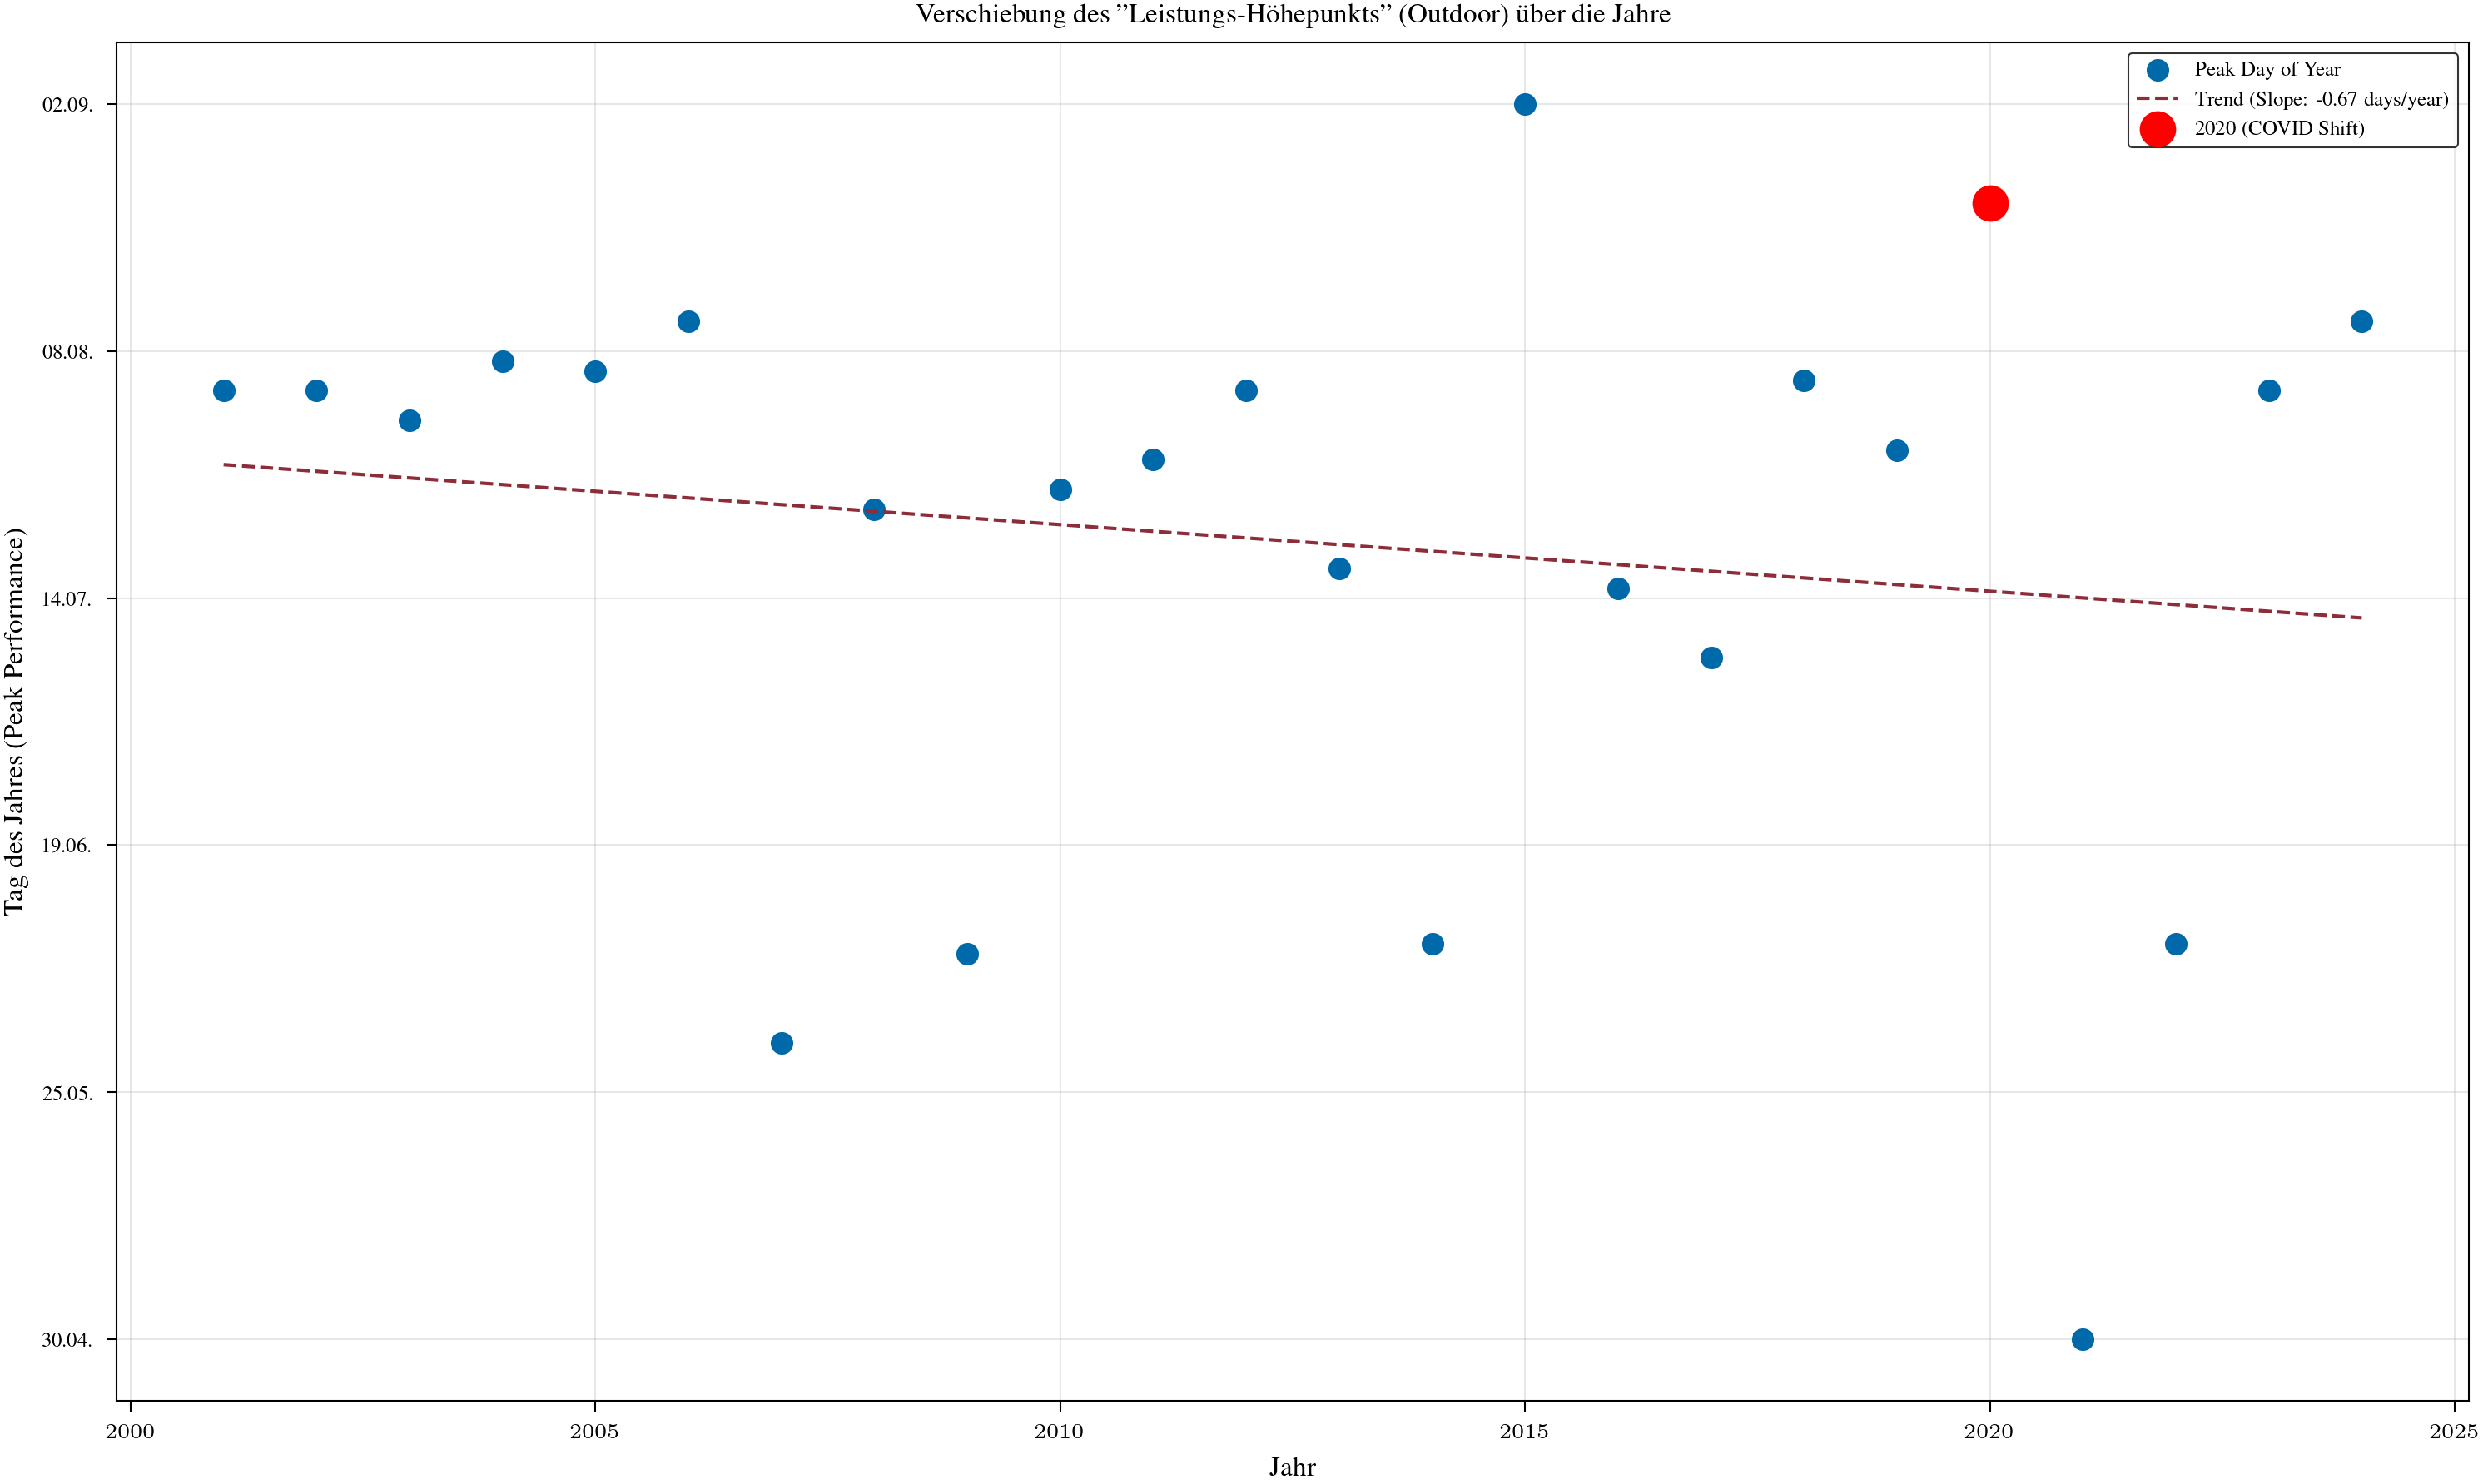

Trend Slope: -0.6748 days per year
Conclusion: The peak season is shifting slightly EARLIER in the year.


In [20]:
peak_days = []
peak_years = []

for y in sorted(years):
    # Filter for year
    y_df = df_clean[df_clean['jahr'] == y]
    # Group by day, calculate mean
    daily_means = y_df.groupby('day_of_year')['iaaf_score'].mean()
    # Smooth (14-day rolling average)
    smoothed = daily_means.rolling(window=14, center=True, min_periods=1).mean()
    
    # Focus only on the "Outdoor Season" window (Day 120 to 250) to avoid finding Indoor peaks
    # Day 120 ~ May 1st, Day 250 ~ Sept 7th
    outdoor_season = smoothed.loc[120:260]
    
    if not outdoor_season.empty:
        # Find the day with the max score
        peak_day = outdoor_season.idxmax()
        peak_days.append(peak_day)
        peak_years.append(y)

# Create DataFrame for analysis
peak_df = pd.DataFrame({'year': peak_years, 'peak_day': peak_days})

# Linear Regression for Trend Line
X = peak_df[['year']]
y = peak_df['peak_day']
model = LinearRegression()
model.fit(X, y)
trend_line = model.predict(X)
slope = model.coef_[0]

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(peak_df['year'], peak_df['peak_day'], color=rgb.tue_blue, label='Peak Day of Year')
plt.plot(peak_df['year'], trend_line, color=rgb.tue_red, linestyle='--', label=f'Trend (Slope: {slope:.2f} days/year)')

# Identify 2020
if 2020 in peak_df['year'].values:
    peak_2020 = peak_df[peak_df['year'] == 2020]['peak_day'].values[0]
    plt.scatter([2020], [peak_2020], color='red', s=100, zorder=5, label='2020 (COVID Shift)')

plt.title('Verschiebung des "Leistungs-Höhepunkts" (Outdoor) über die Jahre')
plt.xlabel('Jahr')
plt.ylabel('Tag des Jahres (Peak Performance)')

# Y-Axis format to dates (approximate)
# Create dummy dates for labeling
import datetime
def day_to_date(day_num):
    return (datetime.datetime(2023, 1, 1) + datetime.timedelta(days=int(day_num) - 1)).strftime("%d.%m.")

# Set specific ticks
yticks = np.linspace(min(peak_days), max(peak_days), 6)
ytick_labels = [day_to_date(d) for d in yticks]
plt.yticks(yticks, ytick_labels)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Trend Slope: {slope:.4f} days per year")
if abs(slope) < 0.1:
    print("Conclusion: No significant shift in the peak season timing.")
elif slope > 0:
    print("Conclusion: The peak season is shifting slightly LATER in the year.")
else:
    print("Conclusion: The peak season is shifting slightly EARLIER in the year.")